In [1]:
from matplotlib import pyplot as plt
import xgboost as xgb
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
from os.path import join, dirname, abspath
import shap
import tqdm

/opt/homebrew/Caskroom/miniconda/base/envs/SaaLab/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
metadata = pd.read_csv(join('..', 'Data', 'metadata.csv')).dropna()
metadata['sample_id'] = metadata['sample_id'].apply(lambda x: str(x).replace('.', '-'))

metadata.set_index('sample_id', inplace = True)
exist_data = pd.read_csv(join('..', 'Data', 'exist.csv'))
exist_data = exist_data.T 
exist_data.columns = exist_data.iloc[0]
exist_data = exist_data[1:]
### Combine metadata and PCA results
metadata_things = metadata[['sex', 'age', 'type_person', 'diagnosis', 'appendectomy', 'smoking']]


concat_meta = pd.concat([metadata_things], axis = 1)
def smoking(x):
    if x == 'Never':
        return 0
    elif x == 'Ex_smoker':
        return 1
    elif x == 'Current_smoker':
        return 2
    else:
        return np.nan
    
    
X = concat_meta.copy()
X.drop(columns = ['type_person', 'diagnosis'], inplace = True)
# encoding
X['sex'] = X['sex'].apply(lambda x: 0 if x == 'Male' else 1)

X['appendectomy'] = X['appendectomy'].apply(lambda x: 0 if x == 'No' else 1)
X['smoking'] = X['smoking'].apply(lambda x: smoking(x))
X = X.astype('category')
y = concat_meta['type_person']
y = y.apply(lambda x: 0 if x == 'Control' else 1)

In [5]:
from sklearn.model_selection import LeaveOneOut, StratifiedKFold
from sklearn.metrics import roc_curve, auc
# LOO CV with optimal features

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 3,
    'eta': 0.1,
    'seed': 100,
    'alpha': 0.2
}




X_opt = X.copy()
y = y.copy()

cv = StratifiedKFold(n_splits = 39, shuffle=True, random_state=42)  
y_true = []
y_pred_proba = []
# make a loo cv
for train_index, test_index in cv.split(X_opt, y):
    X_train, X_test = X_opt.iloc[train_index], X_opt.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    # print(test_index)
    model = XGBClassifier(**params, n_estimators=200, enable_categorical=True)
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:,1]
    y_true.extend(y_test)
    y_pred_proba.extend(y_prob)
    # fpr, tpr, thresholds = roc_curve(y_train, y_prob)

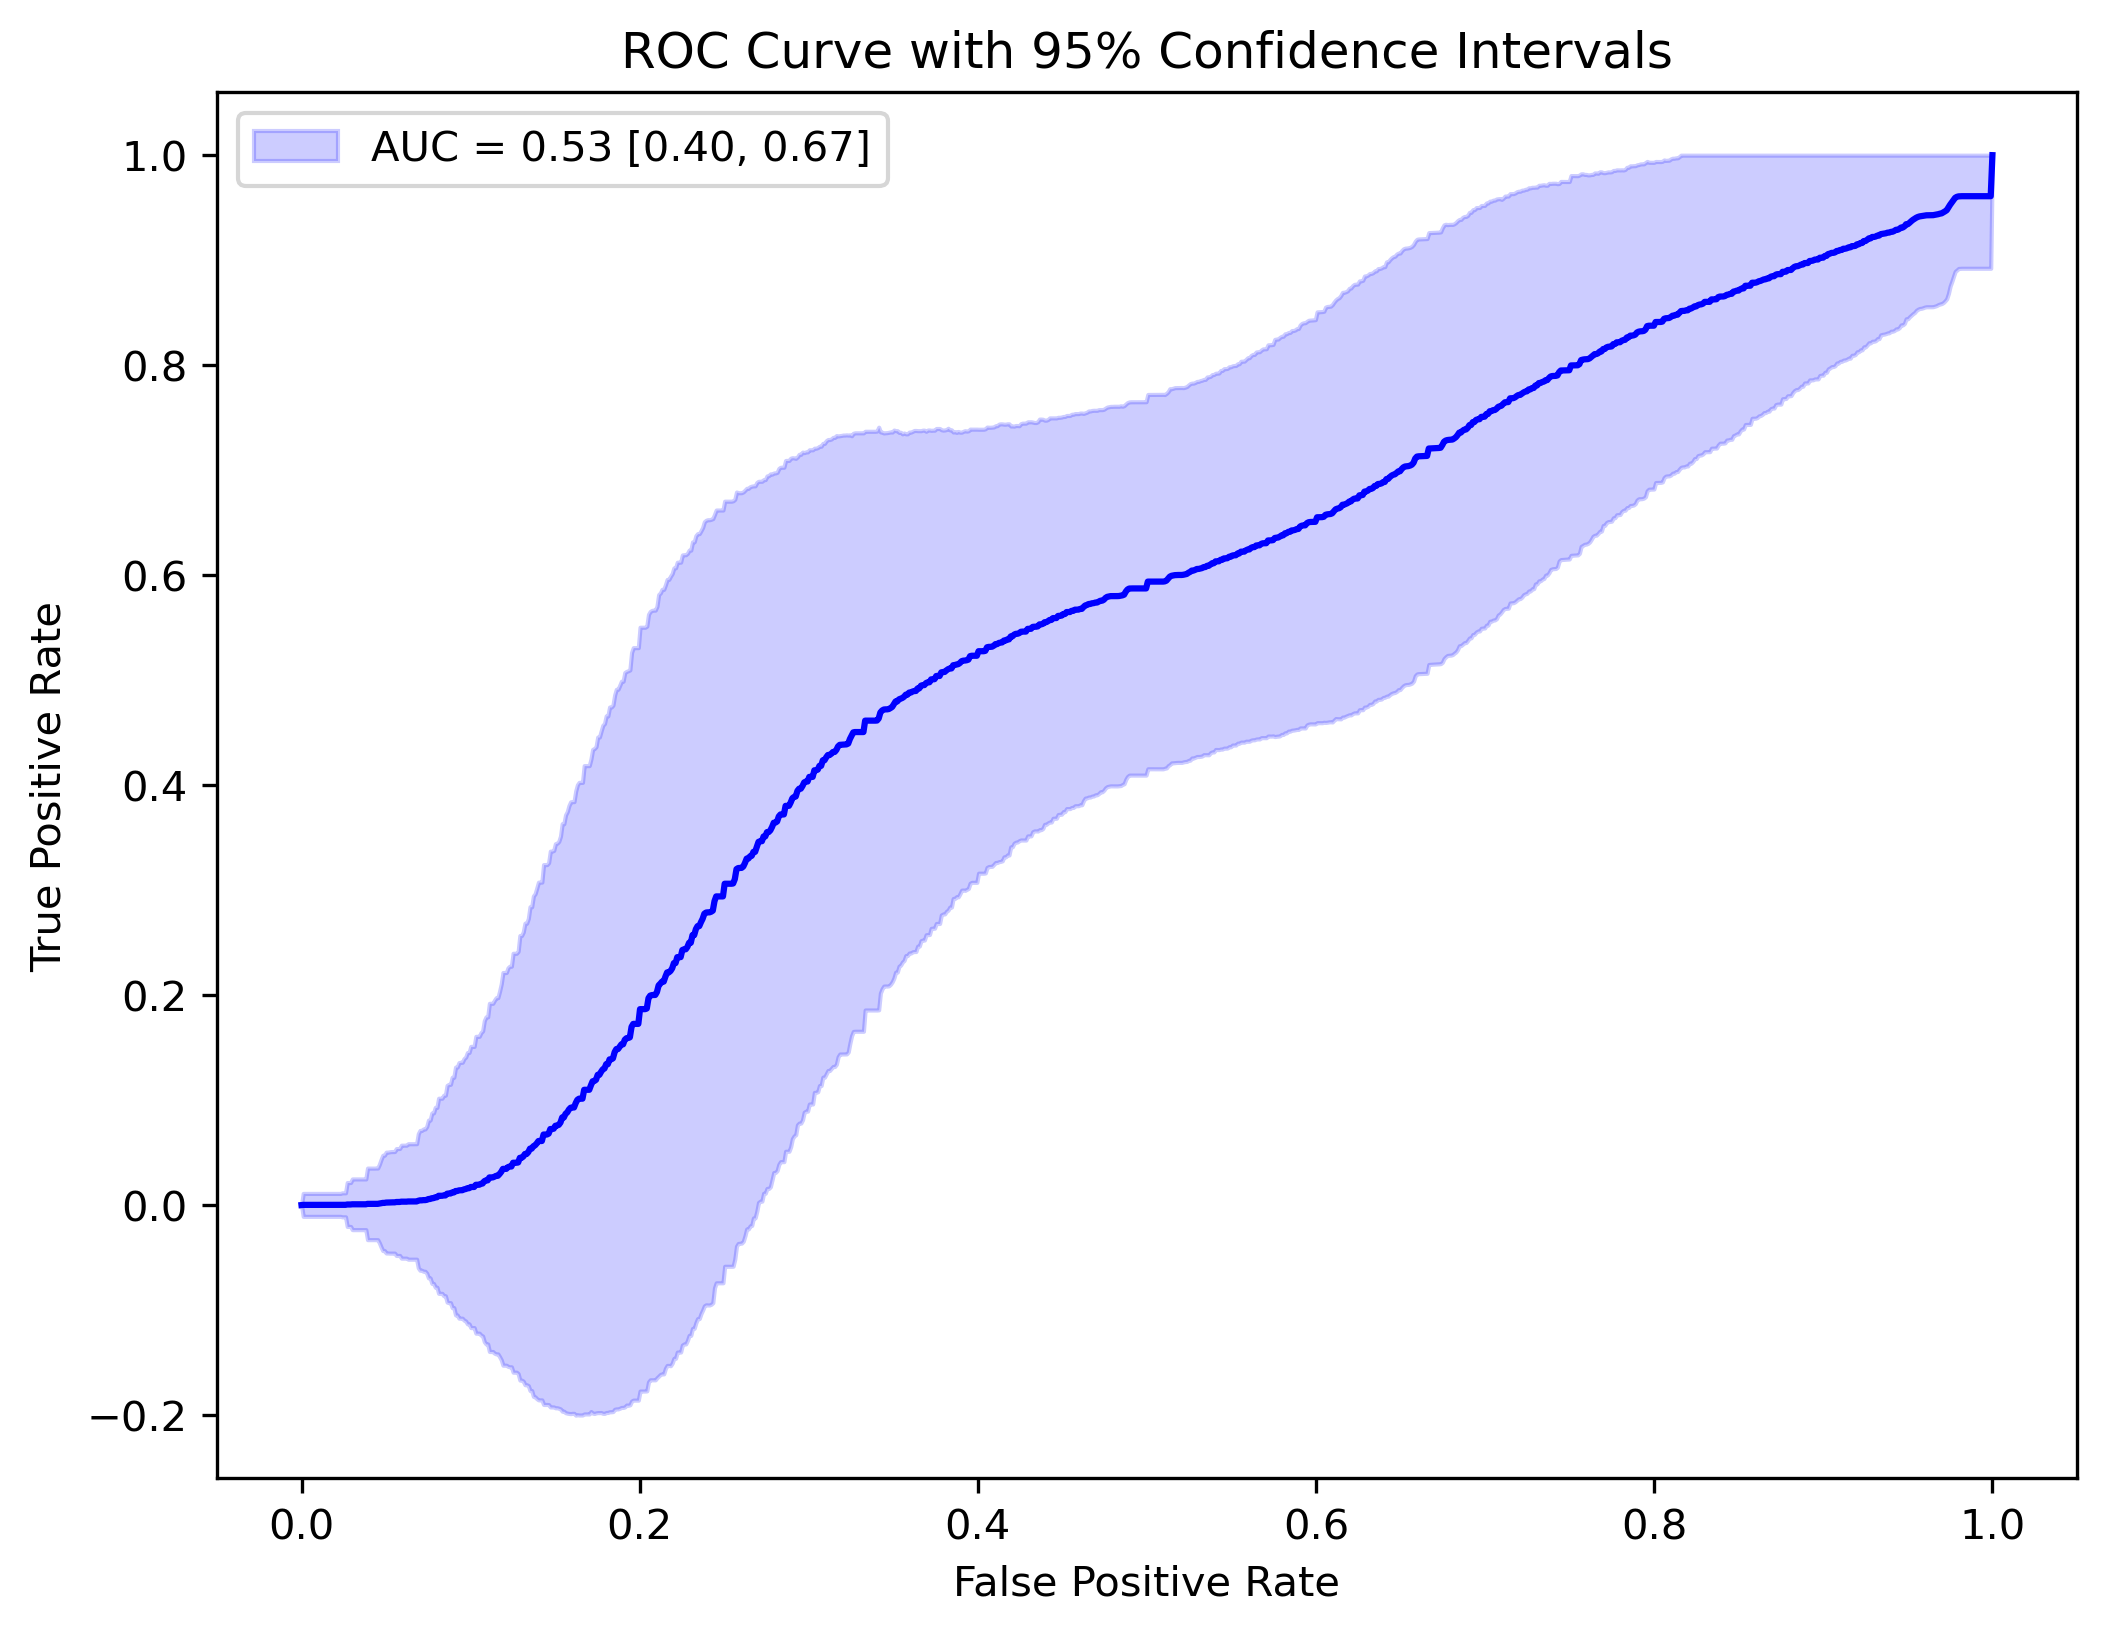

In [6]:
from sklearn.metrics import roc_auc_score
indexes = np.arange(len(y_pred_proba))

samples_indexes = np.random.choice(
    indexes, size=[1000,80], replace=True
)

y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)

fprs = []
tprs = []
aucs = []
for indexes in samples_indexes:
    fpr, tpr , _ = roc_curve(y_true[indexes.astype(int)], y_pred_proba[indexes.astype(int)])
    fprs.append(fpr)
    tprs.append(tpr)
    # plt.plot(fpr, tpr, color='blue', alpha=0.1)
    auc = roc_auc_score(y_true[indexes.astype(int)], y_pred_proba[indexes.astype(int)])
    aucs.append(auc)
fpr_mean    = np.linspace(0, 1, 1000)
interp_tprs = []
for i in range(1000):
    fpr           = fprs[i]
    tpr           = tprs[i]
    interp_tpr    = np.interp(fpr_mean, fpr, tpr)
    interp_tpr[0] = 0.0
    interp_tprs.append(interp_tpr)
tpr_mean     = np.mean(interp_tprs, axis=0)
tpr_mean[-1] = 1.0
tpr_std      = 1.96*np.std(interp_tprs, axis=0)
tpr_upper    = np.clip(tpr_mean+tpr_std, 0, 1)
tpr_lower    = tpr_mean-tpr_std

mean_auc = np.mean(aucs)
auc_sd =np.std(aucs)

df_results_clinical = pd.DataFrame(
    {
        'fpr_mean' :  fpr_mean,
        'tpr_mean' :  tpr_mean,
        'auc_mean' :  mean_auc,
        'auc_sd'   :  auc_sd
    }
)

df_results_clinical.to_csv(join('..', 'Results', 'ROC_CI_clinical.csv'), index=False)

plt.figure(figsize=(8, 6), dpi = 300)
plt.plot(fpr_mean, tpr_mean, color='blue', alpha=1.0)
plt.fill_between(fpr_mean, tpr_lower, tpr_upper, color='blue', alpha=0.2, label = f'AUC = {mean_auc:.2f} [{mean_auc - 2 * auc_sd:.2f}, {mean_auc + 2 * auc_sd:.2f}]')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with 95% Confidence Intervals')
plt.legend()